## Testing Model on real-world NASA dataset

In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error

#### Step1: Loading Previous Models

In [3]:
import joblib

rul_model = joblib.load("../models/rul_model.pkl")
risk_model = joblib.load("../models/risk_model.pkl")

#### Loading Test Dataset

In [4]:
import pandas as pd

columns = ['engine_id','cycle','op1','op2','op3'] + [f'sensor_{i}' for i in range(1,22)]

test = pd.read_csv("../data/raw/test_FD001.txt", sep=r"\s+", names=columns, header=None)
rul = pd.read_csv("../data/raw/RUL_FD001.txt", header=None)

rul.columns = ['RUL']

### Step2: Remove the same sensors removed in Training
**Keeping only these sensor columns:**

sensor_2, sensor_3, sensor_4,
sensor_6, sensor_7, sensor_8, sensor_9,
sensor_11, sensor_12, sensor_13, sensor_14,
sensor_15, sensor_17, sensor_20, sensor_21

In [5]:
keep_cols = [
'engine_id','cycle','op1','op2','op3',
'sensor_2','sensor_3','sensor_4','sensor_6','sensor_7',
'sensor_8','sensor_9','sensor_11','sensor_12','sensor_13',
'sensor_14','sensor_15','sensor_17','sensor_20','sensor_21'
]

test = test[keep_cols]

### Create Same Engineered Features
We must apply same feature engineering used for training.

#### Step1: Identifying sensor columns

In [ ]:
sensor_cols = [col for col in test.columns if "sensor" in col]

#### Step2: Rolling Mean

In [7]:
for sensor in sensor_cols:
    test[f'{sensor}_rolling_mean'] = (
        test.groupby('engine_id')[sensor]
        .rolling(window=5)
        .mean()
        .reset_index(level=0, drop=True)
    )

#### Step3: Rolling Std

In [9]:
for sensor in sensor_cols:
    test[f'{sensor}_rolling_std'] = (
        test.groupby('engine_id')[sensor]
        .rolling(window=5)
        .std()
        .reset_index(level=0, drop=True)
    )

#### Step4: Sensor Delta

In [10]:
for sensor in sensor_cols:
    test[f'{sensor}_delta'] = (
        test.groupby('engine_id')[sensor]
        .diff()
    )

#### Step5: Filling missing values

In [11]:
test = test.fillna(0)

#### Step6: Get Last Cycle of Each Engine
In predictive maintenence evaluation we predict RUL only at the last observed cycle.

In [12]:
test_last = test.groupby('engine_id').last().reset_index()

Checking Shape

In [13]:
test_last.shape

(100, 65)

#### Step7: Predict RUL

In [16]:
# Prepare features for prediction
test_last = test.groupby('engine_id').last().reset_index()

X_test = test_last.drop(columns=['engine_id','cycle'])

predictions = rul_model.predict(X_test)

#### Step8: Evaluate Model

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(rul['RUL'], predictions)
rmse = np.sqrt(mean_squared_error(rul['RUL'], predictions))

print("Test MAE:", mae)
print("Test RMSE:", rmse)

Test MAE: 13.747553971437876
Test RMSE: 18.857502058135086


#### Step9: Visualizing the Result

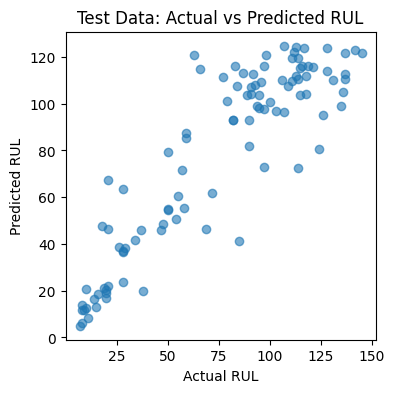

In [20]:
# Visualizing the data
import matplotlib.pyplot as plt

plt.figure(figsize=(4,4))
plt.scatter(rul['RUL'], predictions, alpha=0.6)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Test Data: Actual vs Predicted RUL")
plt.show()